# Data Collection and Loading

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df=pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exploratory Data Analysis (EDA)

## Data Overview

In [4]:
df.shape

(891, 12)

In [5]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Univariate Analysis

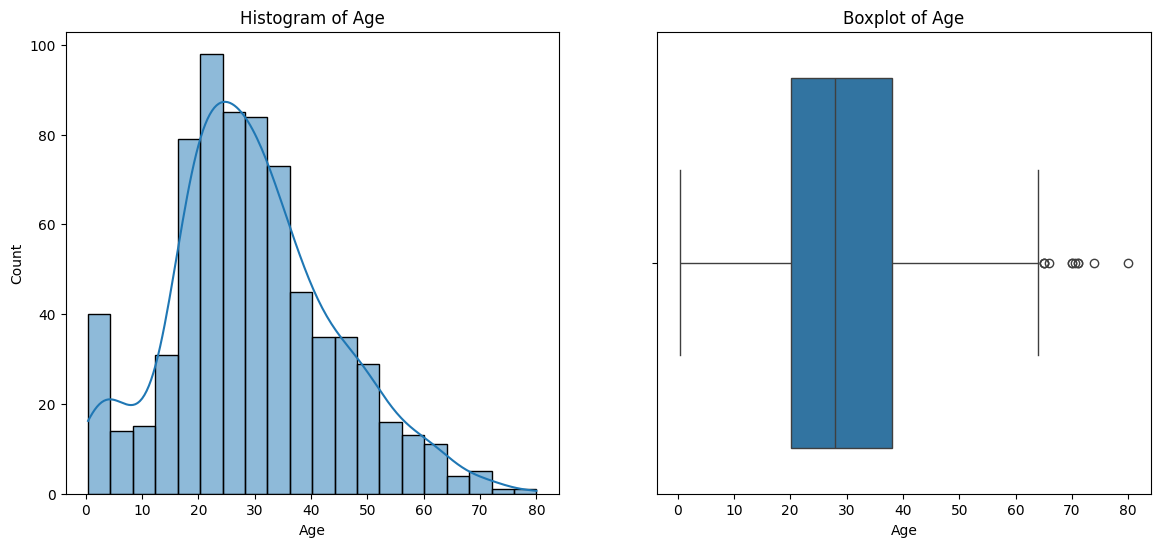

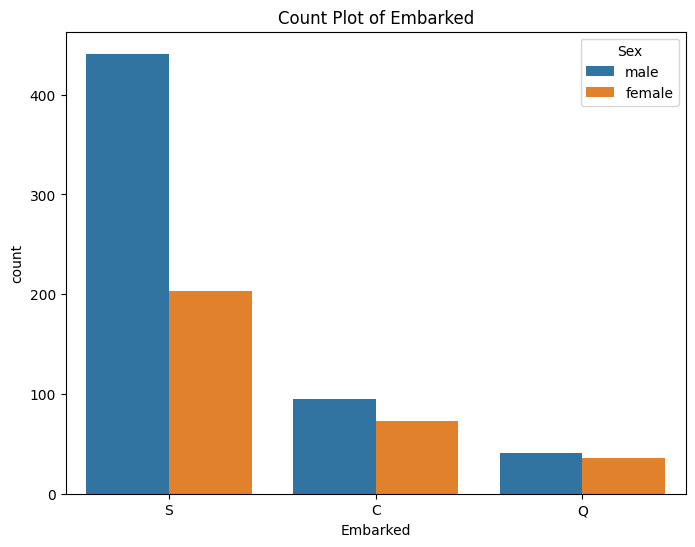

In [9]:
columns_with_null=['Age','Embarked']
for i in columns_with_null:
    if df[i].dtype=='int64' or df[i].dtype == 'float64':
        plt.figure(figsize=(14,6))
        plt.subplot(1,2,1)
        sns.histplot(df[i], bins=20,kde=True)
        plt.title(f"Histogram of {i}")
        plt.subplot(1,2,2)
        sns.boxplot(x=df[i])
        plt.title(f"Boxplot of {i}")
        plt.show()
    else:
        plt.figure(figsize=(8,6))
        sns.countplot(x=df[i],hue=df['Sex'])
        plt.title(f"Count Plot of {i}")
        plt.show()

## Multivariate Analysis

<Axes: >

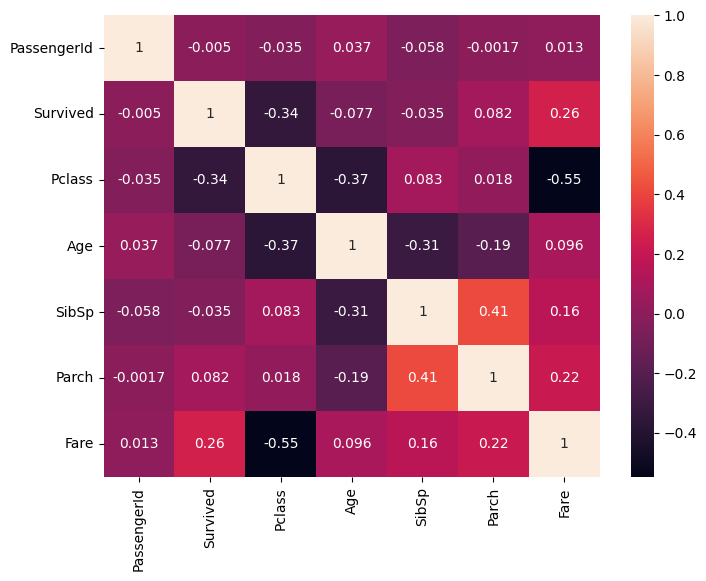

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(data=df.corr(numeric_only=True),annot=True)

## Insights Summary

- Shape: 891 rows, 12 columns.
- Columns: PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked
- Create **Family_Count = SibSp + Parch**
- Drop **Ticket, Cabin** (low predictive value for survival)
- No duplicate rows
- Missing Values: Age (177),  Cabin (68), Embarked (2)
- Univariate Insights: 'Age' is right-skewed with valid real-world outliers, 'Embarked' is mostly category "S"
- Multivariate Insights: No pair of features shows strong correlation in the heatmap

# Data Preprocessing

## Handling Missing Values

In [11]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [12]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

## Remove unwanted columns

In [13]:
df.drop(axis=1,columns=['Ticket', 'Cabin'],inplace=True)

In [14]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


## Title extraction from 'Name'

In [15]:
df['Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())

In [16]:
df.drop('Name', axis=1, inplace=True)

In [17]:
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [18]:
rare_titles = ['Lady','the Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

In [19]:
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

## Create 'IsAlone' feature for higher accuracy

In [20]:
df['Family_Count'] = df['SibSp'] + df['Parch']
df['IsAlone'] = (df['Family_Count'] == 0).astype(int)

In [21]:
df.drop(['SibSp', 'Parch'], axis=1, inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   891 non-null    int64  
 1   Survived      891 non-null    int64  
 2   Pclass        891 non-null    int64  
 3   Sex           891 non-null    object 
 4   Age           891 non-null    float64
 5   Fare          891 non-null    float64
 6   Embarked      891 non-null    object 
 7   Title         891 non-null    object 
 8   Family_Count  891 non-null    int64  
 9   IsAlone       891 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB


## Encoding Categorical Variables

In [23]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

In [24]:
df.head()

,PassengerId,Survived,Pclass,Age,Fare,Family_Count,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,22.0,7.2500,1,0,True,False,True,False,True,False,False
1,2,1,1,38.0,71.2833,1,0,False,False,False,False,False,True,False
2,3,1,3,26.0,7.9250,0,1,False,False,True,True,False,False,False
3,4,1,1,35.0,53.1000,1,0,False,False,True,False,False,True,False
4,5,0,3,35.0,8.0500,0,1,True,False,True,False,True,False,False


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   891 non-null    int64  
 1   Survived      891 non-null    int64  
 2   Pclass        891 non-null    int64  
 3   Age           891 non-null    float64
 4   Fare          891 non-null    float64
 5   Family_Count  891 non-null    int64  
 6   IsAlone       891 non-null    int64  
 7   Sex_male      891 non-null    bool   
 8   Embarked_Q    891 non-null    bool   
 9   Embarked_S    891 non-null    bool   
 10  Title_Miss    891 non-null    bool   
 11  Title_Mr      891 non-null    bool   
 12  Title_Mrs     891 non-null    bool   
 13  Title_Rare    891 non-null    bool   
dtypes: bool(7), float64(2), int64(5)
memory usage: 54.9 KB


## Train–Test Split

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
X_train.shape, y_train.shape

((712, 13), (712,))

In [30]:
X_test.shape, y_test.shape

((179, 13), (179,))

## Feature Scaling

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [32]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [33]:
X_train_scaled

array([[-0.45306593, -1.61413602,  1.25364106, ...,  0.83623203,
        -0.39714428, -0.15639831],
       [ 1.11387354, -0.40055118, -0.47728355, ...,  0.83623203,
        -0.39714428, -0.15639831],
       [-0.25427511,  0.81303367,  0.21508629, ...,  0.83623203,
        -0.39714428, -0.15639831],
       ...,
       [ 1.60890168,  0.81303367,  0.90745614, ...,  0.83623203,
        -0.39714428, -0.15639831],
       [-0.04768856, -1.61413602, -1.1696534 , ..., -1.19584034,
        -0.39714428, -0.15639831],
       [-1.34567573, -1.61413602, -0.63114352, ...,  0.83623203,
        -0.39714428, -0.15639831]])

In [34]:
X_test_scaled

array([[ 1.02032491,  0.81303367, -0.09263364, ..., -1.19584034,
        -0.39714428, -0.15639831],
       [-0.03209712, -0.40055118,  0.13815631, ...,  0.83623203,
        -0.39714428, -0.15639831],
       [ 1.53094449,  0.81303367, -0.7080735 , ...,  0.83623203,
        -0.39714428, -0.15639831],
       ...,
       [-1.64581091,  0.81303367,  0.67666619, ..., -1.19584034,
         2.51797661, -0.15639831],
       [-1.4158372 , -0.40055118, -0.93886345, ..., -1.19584034,
        -0.39714428, -0.15639831],
       [-1.7042788 ,  0.81303367, -1.93895323, ..., -1.19584034,
        -0.39714428, -0.15639831]])

# Model Training and Evaluation

In [35]:
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

2026-03-17 19:06:34.486754: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773774394.784596      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773774394.863550      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773774395.546958      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773774395.547034      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773774395.547038      17 computation_placer.cc:177] computation placer alr

In [36]:
model=keras.Sequential([
    keras.layers.Input(shape=(13,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

2026-03-17 19:07:06.312512: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [37]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [38]:
from keras.callbacks import EarlyStopping
early_stop= EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [39]:
history=model.fit(X_train_scaled,y_train,validation_split=0.3,epochs=100,batch_size=32,callbacks=[early_stop])

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4477 - loss: 0.7179 - val_accuracy: 0.5935 - val_loss: 0.6843
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5576 - loss: 0.6842 - val_accuracy: 0.6589 - val_loss: 0.6585
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6165 - loss: 0.6652 - val_accuracy: 0.6729 - val_loss: 0.6377
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6763 - loss: 0.6402 - val_accuracy: 0.6869 - val_loss: 0.6151
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6808 - loss: 0.6309 - val_accuracy: 0.7056 - val_loss: 0.5906
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6938 - loss: 0.6181 - val_accuracy: 0.7383 - val_loss: 0.5637
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6999 - loss: 0.6001 - val_accuracy: 0.7757 - val_loss: 0.5373
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7222 - loss: 0.5708 - val_accuracy: 0.7991 - 

In [40]:
loss, acc = model.evaluate(X_test_scaled, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8297 - loss: 0.4082 


# Save model

In [41]:
import joblib
joblib.dump(model, "ann_model.pkl")

['ann_model.pkl']

# Kaggle Submission

## Import test dataset

In [42]:
test_data=pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [43]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


## Test Data Preprocessing

### Handling missing values

In [44]:
test_data['Age']=test_data['Age'].fillna(test_data['Age'].median())
test_data['Embarked'] = test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])

### Remove unwanted columns

In [45]:
test_data.drop(axis=1,columns=['Ticket', 'Cabin'],inplace=True)

In [46]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,S


### Title extraction from 'Name'

In [47]:
test_data['Title'] = test_data['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
test_data.drop('Name', axis=1, inplace=True)
test_data['Title'] = test_data['Title'].replace(['Mlle', 'Ms'], 'Miss')
test_data['Title'] = test_data['Title'].replace('Mme', 'Mrs')
rare_titles = ['Lady','the Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
test_data['Title'] = test_data['Title'].replace(rare_titles, 'Rare')
test_data['Title'].value_counts()

Title
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64

### Create 'IsAlone' feature for higher accuracy

In [48]:
test_data['Family_Count'] = test_data['SibSp'] + test_data['Parch']
test_data['IsAlone'] = (test_data['Family_Count'] == 0).astype(int)
test_data.drop(['SibSp', 'Parch'], axis=1, inplace=True)
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   418 non-null    int64  
 1   Pclass        418 non-null    int64  
 2   Sex           418 non-null    object 
 3   Age           418 non-null    float64
 4   Fare          417 non-null    float64
 5   Embarked      418 non-null    object 
 6   Title         418 non-null    object 
 7   Family_Count  418 non-null    int64  
 8   IsAlone       418 non-null    int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 29.5+ KB


### Encoding categorical variables

In [49]:
test_data = pd.get_dummies(test_data, columns=['Sex', 'Embarked', 'Title'], drop_first=True)
test_data.head()

,PassengerId,Pclass,Age,Fare,Family_Count,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,892,3,34.5,7.8292,0,1,True,True,False,False,True,False,False
1,893,3,47.0,7.0000,1,0,False,False,True,False,False,True,False
2,894,2,62.0,9.6875,0,1,True,True,False,False,True,False,False
3,895,3,27.0,8.6625,0,1,True,False,True,False,True,False,False
4,896,3,22.0,12.2875,2,0,False,False,True,False,False,True,False


In [50]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   418 non-null    int64  
 1   Pclass        418 non-null    int64  
 2   Age           418 non-null    float64
 3   Fare          417 non-null    float64
 4   Family_Count  418 non-null    int64  
 5   IsAlone       418 non-null    int64  
 6   Sex_male      418 non-null    bool   
 7   Embarked_Q    418 non-null    bool   
 8   Embarked_S    418 non-null    bool   
 9   Title_Miss    418 non-null    bool   
 10  Title_Mr      418 non-null    bool   
 11  Title_Mrs     418 non-null    bool   
 12  Title_Rare    418 non-null    bool   
dtypes: bool(7), float64(2), int64(4)
memory usage: 22.6 KB


### Feature scaling

In [51]:
test_data_scaled=scaler.transform(test_data)
test_data_scaled

array([[ 1.72973532,  0.81303367,  0.40741125, ...,  0.83623203,
        -0.39714428, -0.15639831],
       [ 1.73363318,  0.81303367,  1.36903603, ..., -1.19584034,
         2.51797661, -0.15639831],
       [ 1.73753104, -0.40055118,  2.52298578, ...,  0.83623203,
        -0.39714428, -0.15639831],
       ...,
       [ 3.34734697,  0.81303367,  0.71513118, ...,  0.83623203,
        -0.39714428, -0.15639831],
       [ 3.35124483,  0.81303367, -0.16956362, ...,  0.83623203,
        -0.39714428, -0.15639831],
       [ 3.35514269,  0.81303367, -0.16956362, ..., -1.19584034,
        -0.39714428, -0.15639831]])

## Load model

In [52]:
model = joblib.load("ann_model.pkl")

## Predict on test data

In [53]:
test_predictions = model.predict(test_data_scaled)
test_predictions = (test_predictions > 0.5).astype(int).flatten()
test_predictions

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

## Save predictions

In [54]:
submission=pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived":test_predictions.astype(int)
})

In [55]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [56]:
submission.to_csv("Submission_ANN.csv", index=False)